In [1]:
from objects import word, make_whitehead_graph, draw_whitehead_graph, genRandWord, getFreeGroup, make_directed
from graph_tool.all import boykov_kolmogorov_max_flow, Graph, EdgePropertyMap, min_st_cut

/nix/store/gdyl89d3lgffvxb3qjqlh91m12x8lifr-python3-3.13.12-env/lib/python3.13/site-packages/graph_tool/draw/cairo_draw.py:1553: RuntimeWarning: Error importing Gtk module: ; GTK+ drawing will not work.
  warnings.warn(msg, RuntimeWarning)


g^9 e^3 f^12 e^-18 a^11 f^-19 g^-17 f^18 e^-9 b^1 e^-10 b^-11 d^-2 f^16 a^2 c^-11 e^-5 d^1 e^11 b^5 e^17 c^9 b^-7 f^-10 d^13 b^-6 g^-11 b^-14 c^-10 f^-13 b^16 f^-14 g^-6 c^-16 e^1 a^-15 f^-13 a^-9 b^4 c^19 e^-12 d^2 f^-20 a^-17 g^6 c^7 d^2 g^-5 b^-14 e^12 b^9 e^-4 c^-6 a^-16 g^-13 b^-20 g^-17 f^11 c^10 f^3 g^-17 e^-16 f^-17 c^-13 f^-2 a^2 c^10 g^15 a^-15 c^10 g^-13 a^10 c^3 g^-14 d^20 f^6 g^4 e^-5 d^1 e^12 a^-2 b^-4 e^-1 g^-9 f^8 a^3 c^-19 a^-14 e^16 g^18 a^-12 d^18 f^-9 d^5 a^-20 d^-18
g g⁻¹ 174
g⁻¹ g 174
e⁻¹ e 152
e e⁻¹ 152
f⁻¹ f 191
f f⁻¹ 191
a⁻¹ a 148
a a⁻¹ 148
b⁻¹ b 111
b b⁻¹ 111
d d⁻¹ 82
d⁻¹ d 82
c c⁻¹ 143
c⁻¹ c 143


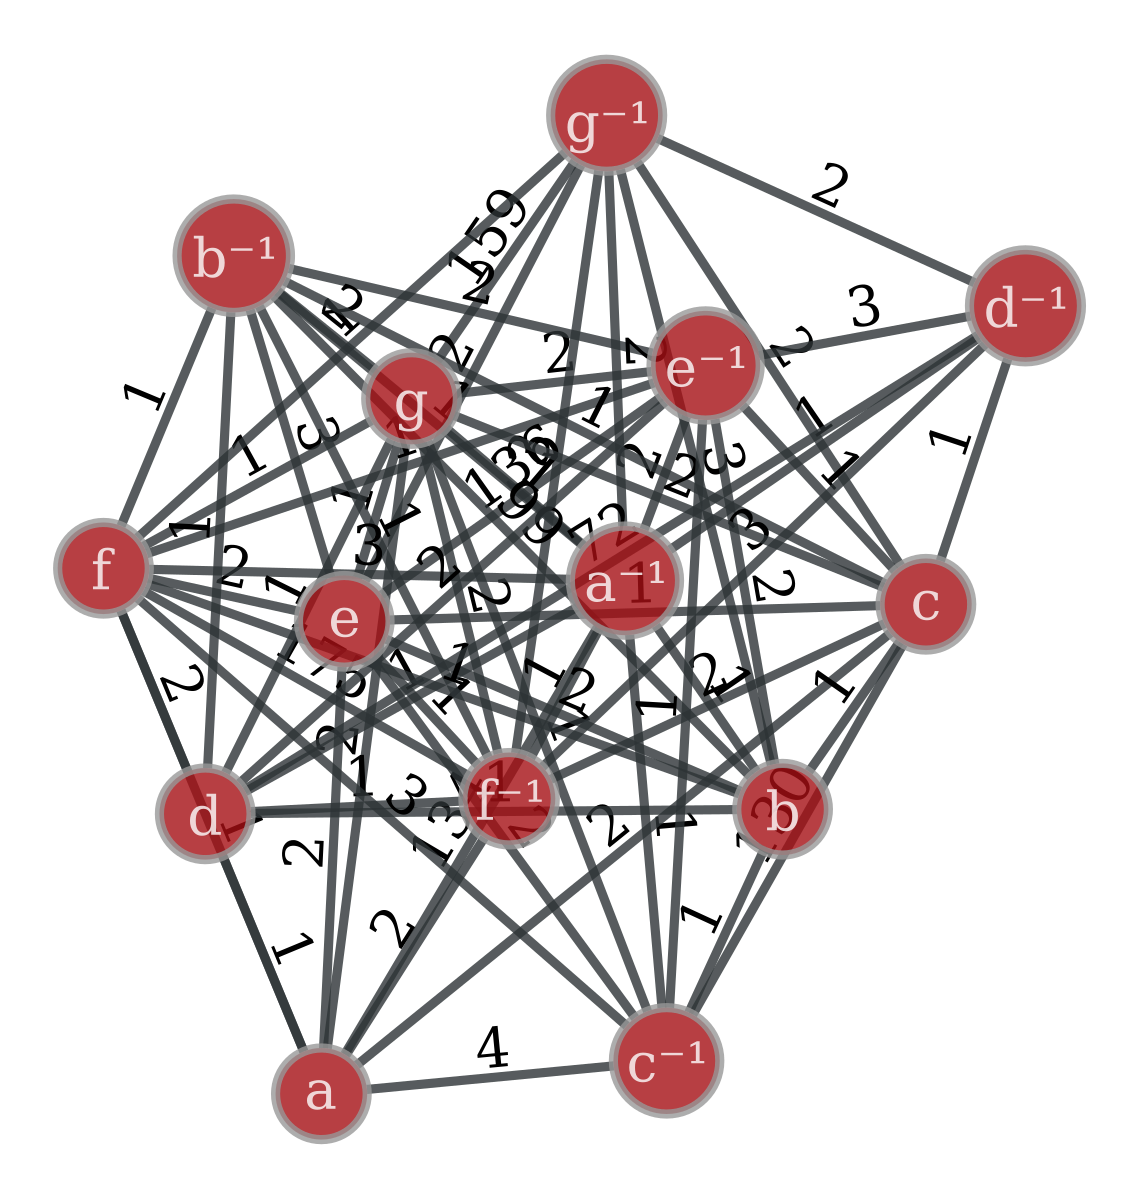

In [88]:
w, _ = genRandWord(getFreeGroup(3), 100, 20)
print(w.get_copyable())
g = make_whitehead_graph(w)
inv = g.vp["inv_vertex"]
elem = g.vp["elem"]
weight = g.ep["weight"]
for i in g.vertices():
    print(elem[i], elem[inv[i]], i.out_degree(weight))
draw_whitehead_graph(g)

In [111]:
def find_partitions(g):
    dg = make_directed(g)
    cap = dg.ep["weight"]
    elem = dg.vp["elem"]
    partitions = []
    for src in dg.vertices():
        tgt = dg.vertex(inv[src])
        cap = dg.ep["weight"]
        res = boykov_kolmogorov_max_flow(dg, src, tgt, cap)
        part = min_st_cut(dg, src, cap, res)
        temp = [cap[e] for e in dg.edges() if part[e.source()] != part[e.target()]]
        mc = sum(temp)//2
        # print(elem[src], "Degree:", src.out_degree(cap), "MinCut:", mc)
        # print(temp)
        if mc < src.out_degree(cap):
            draw_whitehead_graph(dg, part=part)
            part1 = set()
            part2 = set()
            for v in dg.vertices():
                (part1 if part[v] else part2).add(elem[v])
            partitions.append((part1, part2))
    return partitions

In [116]:
def create_test():
    w, _ = genRandWord(getFreeGroup(3), 100, 20)
    if w.word[-1].sym == w.word[0].sym:
        w.word = w.word[:-1:]
    g = make_whitehead_graph(w)
    return g, w

||||

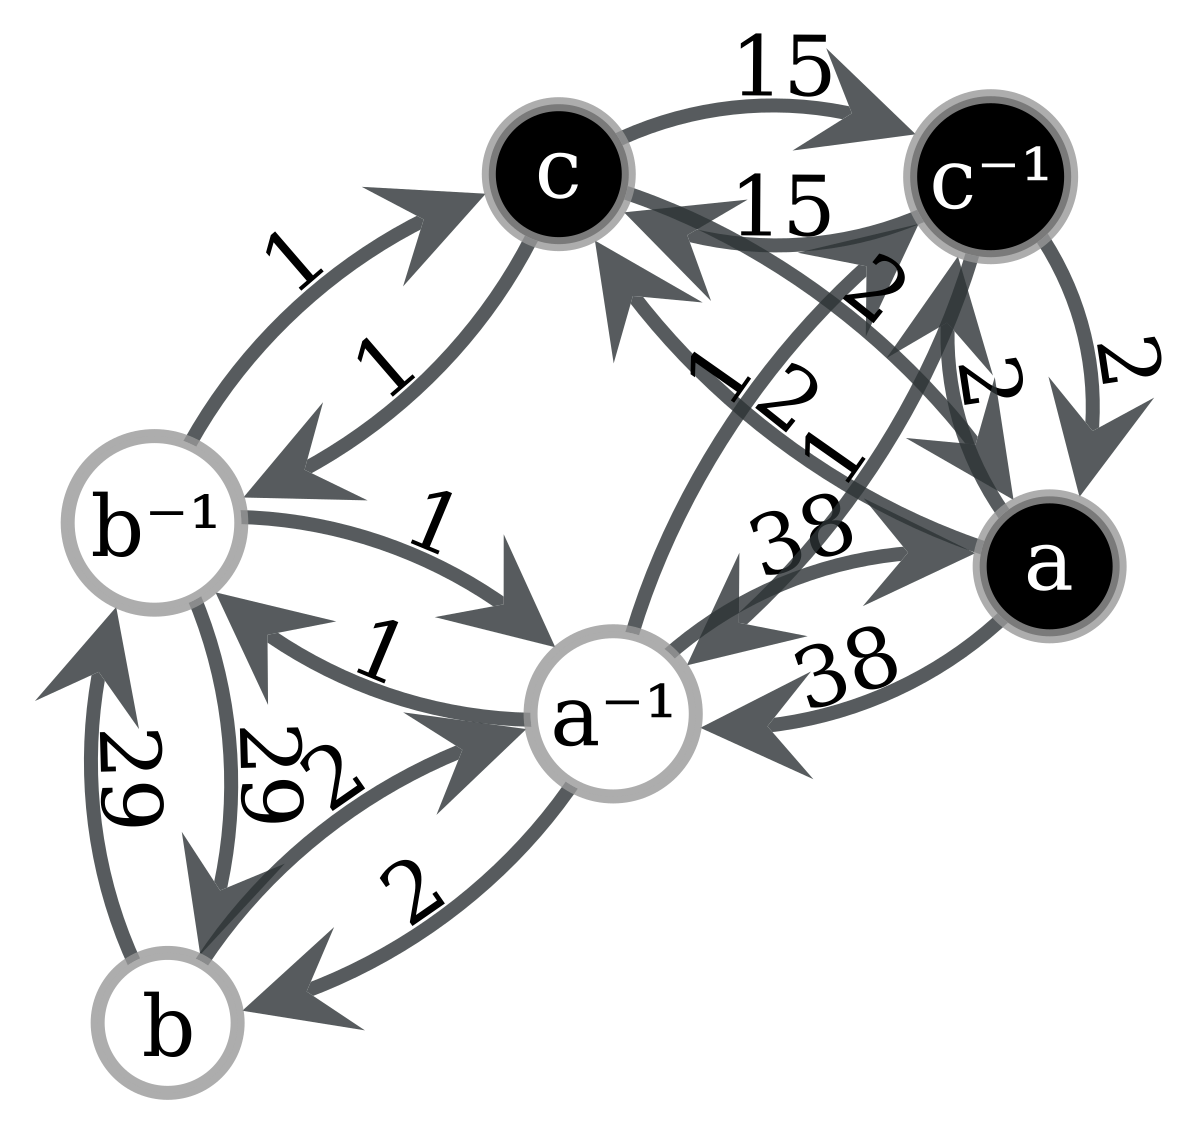

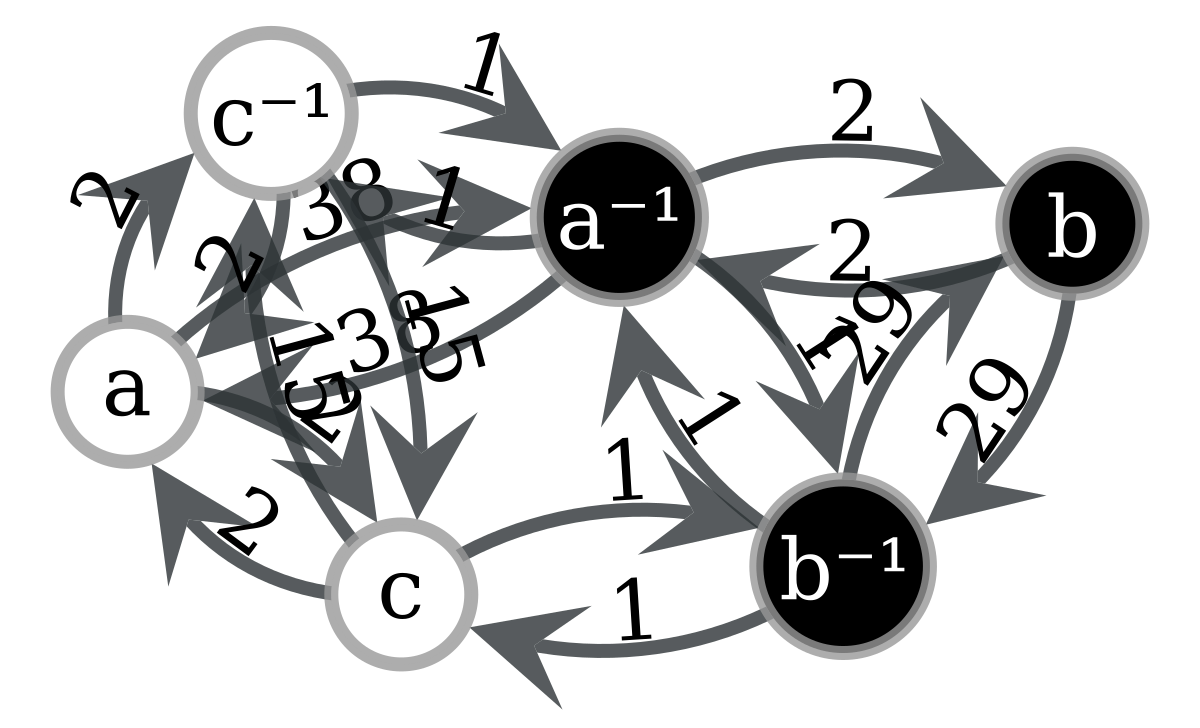

[({a, c, c⁻¹}, {b⁻¹, b, a⁻¹}), ({b⁻¹, b, a⁻¹}, {a, c, c⁻¹})] a^6 c^-14 a^-13 b^-13 c^-1 a^-5 b^18 a^18 c^-3


In [117]:
p = []
while p == []:
    g, w = create_test()
    print("|", end="")
    p = find_partitions(g)
print(p, w.get_copyable())

In [85]:
# def make_directed(whg : Graph):
#     d_whg = Graph(whg)
#     d_whg.set_directed(True)
#     d_whg.clear_edges()
#     weight = whg.ep["weight"]
#     rev_edge_list = []
#     new_weight = d_whg.new_ep("int")
#     for e in whg.iter_edges(eprops=[weight]):
#         rev_edge_list.append((e[0], e[1], e[2]))
#         rev_edge_list.append((e[1], e[0], e[2]))
#     d_whg.add_edge_list(rev_edge_list, eprops = [new_weight])
#     d_whg.ep["weight"] = new_weight

<VertexPropertyMap object with value type 'python::object', for Graph 0x7ad39e713110, at 0x7ad39e887700>


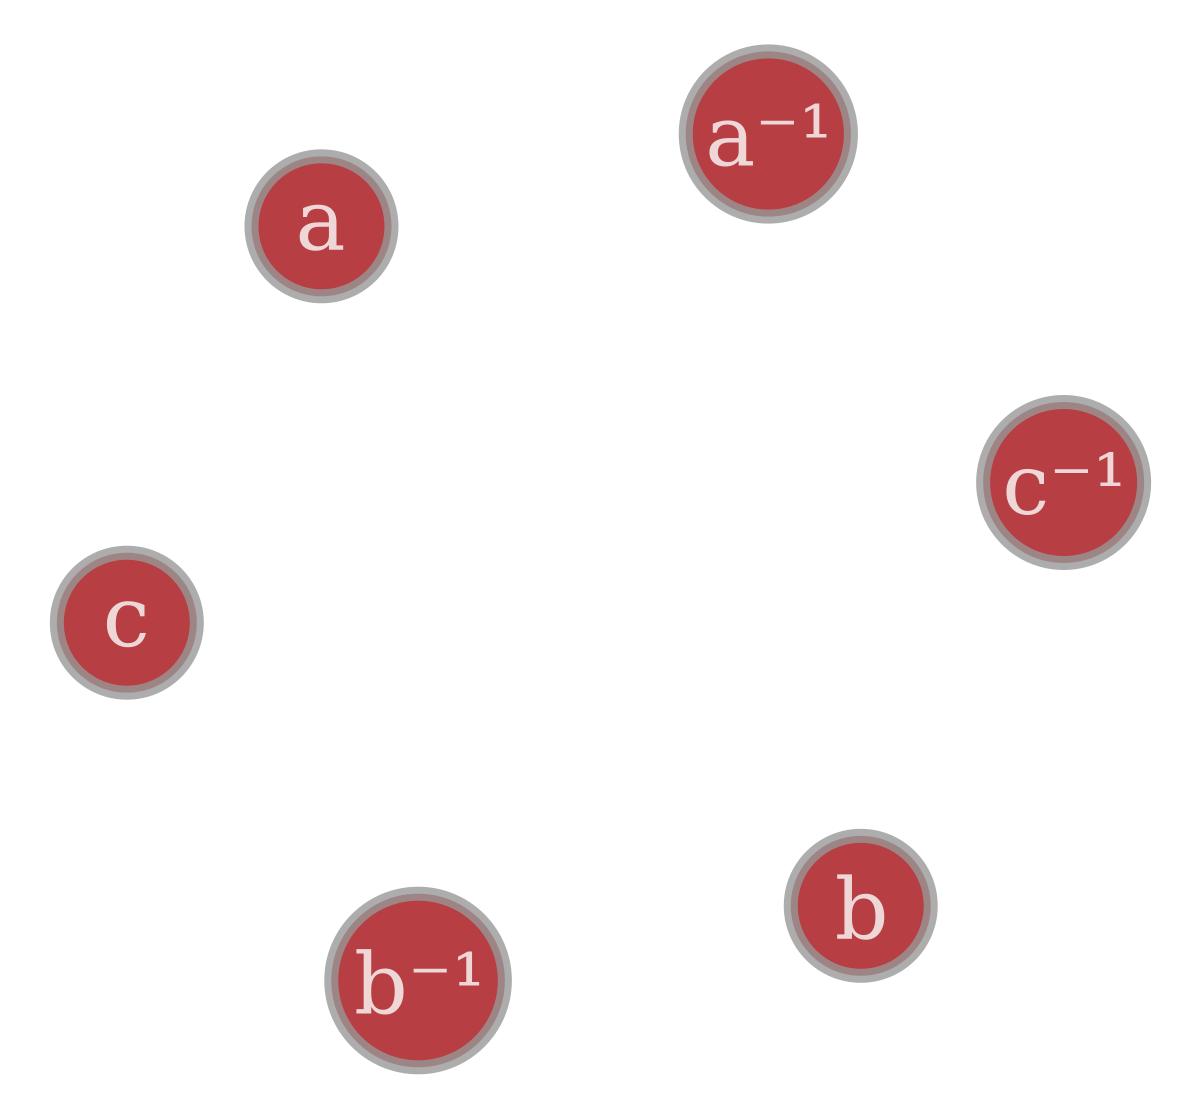

[(0, 1, 1), (1, 0, 1), (0, 2, 1), (2, 0, 1), (2, 5, 1), (5, 2, 1), (3, 2, 3), (2, 3, 3), (3, 4, 1), (4, 3, 1), (4, 1, 1), (1, 4, 1), (5, 4, 3), (4, 5, 3), (5, 3, 1), (3, 5, 1)]
<VertexPropertyMap object with value type 'python::object', for Graph 0x7ad39e713110, at 0x7ad39e887700>


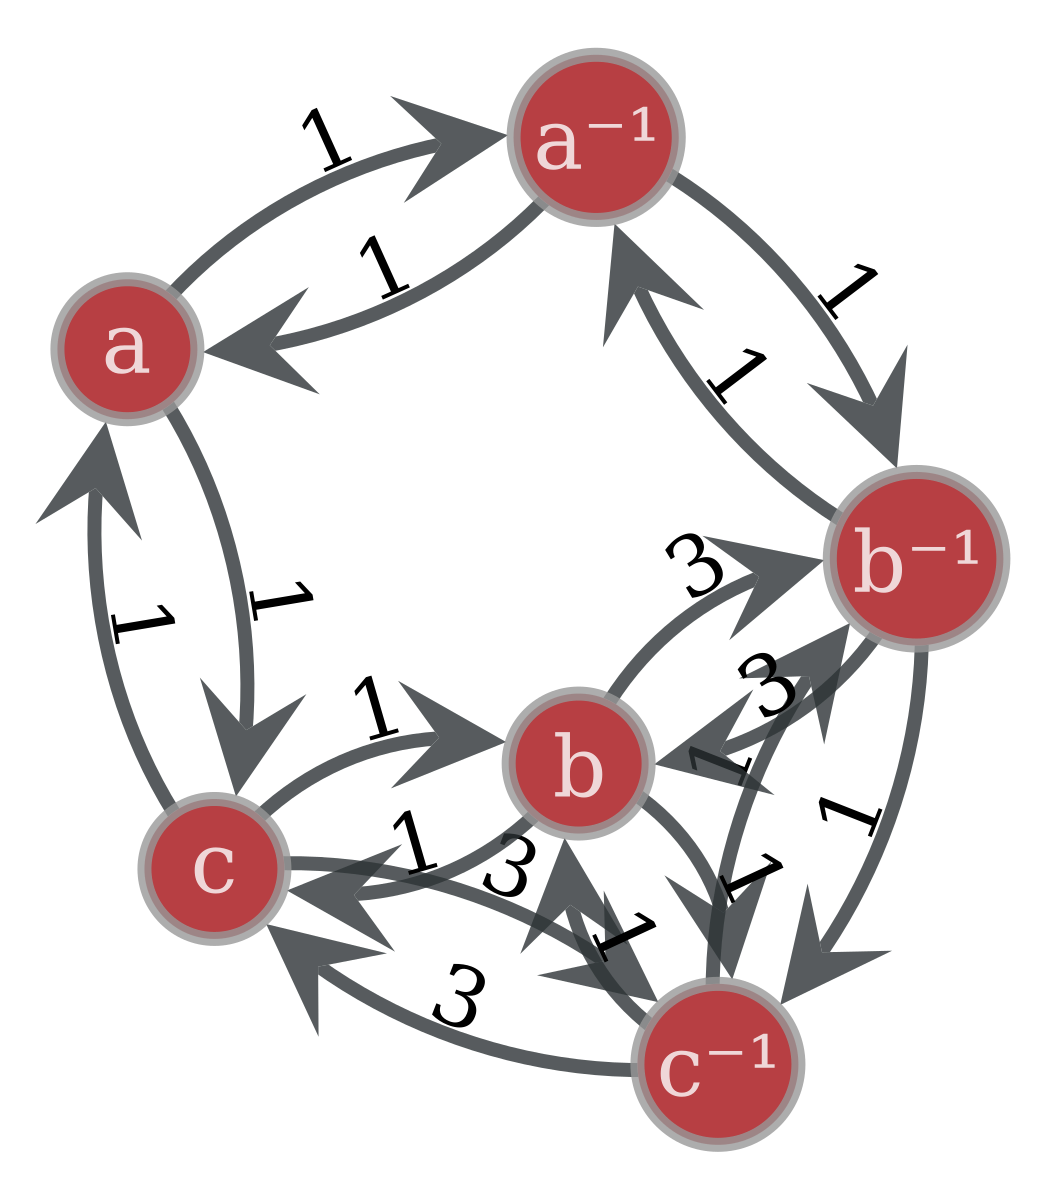

In [31]:
[({'a'}, ] == 

True